# **Decision Tree Classification — Hands-on Demo**

This notebook is a **hands-on companion** to the Decision Tree (Classification) notes.

**What you'll see in this notebook:**
1. The classic **"Play Tennis"** dataset (14 records) used throughout the notes
2. Computing **Entropy** and **Gini Impurity** by hand — and confirming the numbers match the notes exactly
3. Computing **Information Gain** for every feature to confirm `Outlook` really does win as the root split
4. Visualizing the **Entropy vs Gini curves** (why Entropy peaks at 1, Gini at 0.5)
5. Training an actual `sklearn` `DecisionTreeClassifier` and **visualizing the resulting tree**
6. A **continuous-feature splitting** demo (trying every threshold, just like Section 7 of the notes)
7. A **Pre-Pruning vs Post-Pruning** demo showing overfitting in action, and how to fix it

> **Real-life analogy reminder:** A Decision Tree is just automatically-learned if/else logic —
> like a nurse doing triage: *"Fever > 103°F? → Difficulty breathing? → Send to ER."*


## 1. The Play Tennis Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play':        ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No'],
}
df = pd.DataFrame(data)
print(df['Play'].value_counts())
df


Play
Yes    9
No     5
Name: count, dtype: int64


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


## 2. Entropy and Gini Impurity — Computed By Hand

Let's write the formulas directly and confirm they match the notes:
- Root entropy should be **≈ 0.940**
- The `Overcast` branch should be **perfectly pure (entropy = 0)**

In [ ]:
import numpy as np

# Function to calculate Entropy
def entropy(labels):
    """
    Calculates the entropy of a set of class labels.

    Parameters:
        labels : Array-like
            Target class labels (e.g., Yes/No)

    Returns:
        float
            Entropy value
    """

    # np.unique() returns:
    #   1. Unique class labels
    #   2. Count of each class
    #
    # We don't need the unique labels themselves,
    # so '_' is used as a throwaway variable.
    #
    # Example:
    # labels = ['Yes', 'No', 'Yes', 'Yes']
    #
    # np.unique(labels, return_counts=True)
    # returns:
    # (['No', 'Yes'], [1, 3])
    #
    # '_' receives ['No', 'Yes']
    # counts receives [1, 3]
    _, counts = np.unique(labels, return_counts=True)

    # Convert counts into probabilities.
    #
    # Example:
    # counts = [5, 9]
    #
    # Total = 14
    #
    # p = [5/14, 9/14]
    p = counts / counts.sum()

    # Entropy Formula:
    #
    # H(S) = -Σ p_i log₂(p_i)
    #
    # Higher entropy
    # -> more mixed classes
    #
    # Lower entropy
    # -> purer classes
    return -np.sum(p * np.log2(p))

# Function to calculate Gini Impurity
def gini(labels):
    """
    Calculates the Gini Impurity of a set of class labels.

    Parameters:
        labels : Array-like
            Target class labels

    Returns:
        float
            Gini Impurity
    """

    # Again, ignore the unique class names
    # and keep only their counts.
    _, counts = np.unique(labels, return_counts=True)

    # Convert counts into probabilities.
    p = counts / counts.sum()

    # Gini Formula:
    #
    # Gini = 1 - Σ(p_i²)
    #
    # Lower Gini
    # -> purer node
    #
    # Higher Gini
    # -> mixed node
    return 1 - np.sum(p ** 2)


# Calculate impurity of the ROOT node

# Entropy before any split
root_entropy = entropy(df["Play"])

# Gini before any split
root_gini = gini(df["Play"])

print(f"Root Entropy: {root_entropy:.4f}")
print(f"Root Gini:    {root_gini:.4f}")


# Calculate impurity after splitting by Outlook

print("\nSplitting by Outlook:")

# Group the dataset according to each unique
# Outlook value (Sunny, Overcast, Rain)
for outlook, group in df.groupby("Outlook"):

    # Display:
    #   - class distribution
    #   - entropy
    #   - gini impurity
    print(
        f"{outlook:>9}: "
        f"{group['Play'].value_counts().to_dict()}  "
        f"Entropy = {entropy(group['Play']):.4f}  "
        f"Gini = {gini(group['Play']):.4f}"
    )

Root Entropy: 0.9403
Root Gini:    0.4592

Splitting by Outlook:
 Overcast: {'Yes': 4}  Entropy = -0.0000  Gini = 0.0000
     Rain: {'Yes': 3, 'No': 2}  Entropy = 0.9710  Gini = 0.4800
    Sunny: {'No': 3, 'Yes': 2}  Entropy = 0.9710  Gini = 0.4800


## 3. Information Gain — Which Feature Should Be the Root?

We compute Information Gain for **all 4 features** and confirm `Outlook` wins — exactly as the notes claim.

In [ ]:
def information_gain(df, feature, target='Play'):
    root_e = entropy(df[target])
    weighted = sum(
        (len(group) / len(df)) * entropy(group[target])
        for _, group in df.groupby(feature)
    )
    return root_e - weighted

print("Information Gain per feature:")
gains = {}
for feat in ['Outlook', 'Temperature', 'Humidity', 'Wind']:
    ig = information_gain(df, feat)
    gains[feat] = ig
    print(f"  {feat:<12}: {ig:.4f}")

best_feature = max(gains, key=gains.get)
print(f"\n>>> Best root split: '{best_feature}' (highest Information Gain) <<<")


Information Gain per feature:
  Outlook     : 0.2467
  Temperature : 0.0292
  Humidity    : 0.1518
  Wind        : 0.0481

>>> Best root split: 'Outlook' (highest Information Gain) <<<


## 4. Visualizing the Entropy vs Gini Curves

Both formulas measure "how mixed up" a binary split is — but their maximum values differ (1 vs 0.5).

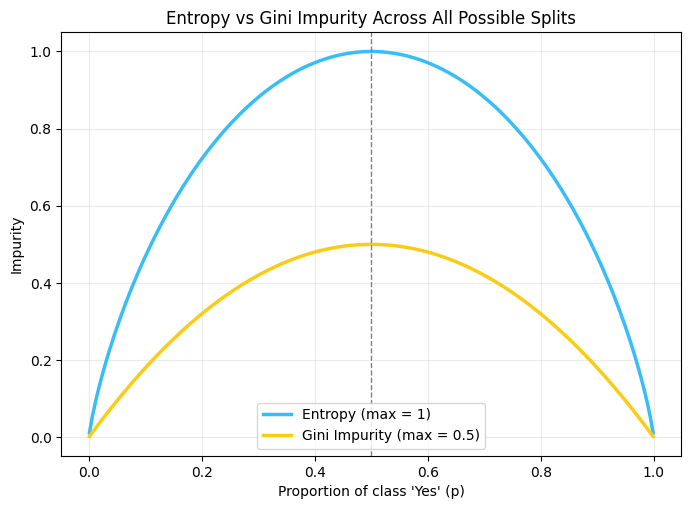

Both curves peak at p=0.5 (a perfect 50/50 mix) and hit 0 at the extremes (pure nodes).


In [ ]:
p = np.linspace(0.001, 0.999, 200)
entropy_curve = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
gini_curve = 1 - p**2 - (1 - p)**2

plt.figure(figsize=(8, 5.5))
plt.plot(p, entropy_curve, label="Entropy (max = 1)", color="#38bdf8", linewidth=2.5)
plt.plot(p, gini_curve, label="Gini Impurity (max = 0.5)", color="#facc15", linewidth=2.5)
plt.axvline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Proportion of class 'Yes' (p)")
plt.ylabel("Impurity")
plt.title("Entropy vs Gini Impurity Across All Possible Splits")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print("Both curves peak at p=0.5 (a perfect 50/50 mix) and hit 0 at the extremes (pure nodes).")


## 5. Training a Real `sklearn` Decision Tree

Now let's encode the categorical features and train an actual `DecisionTreeClassifier`, then visualize it.

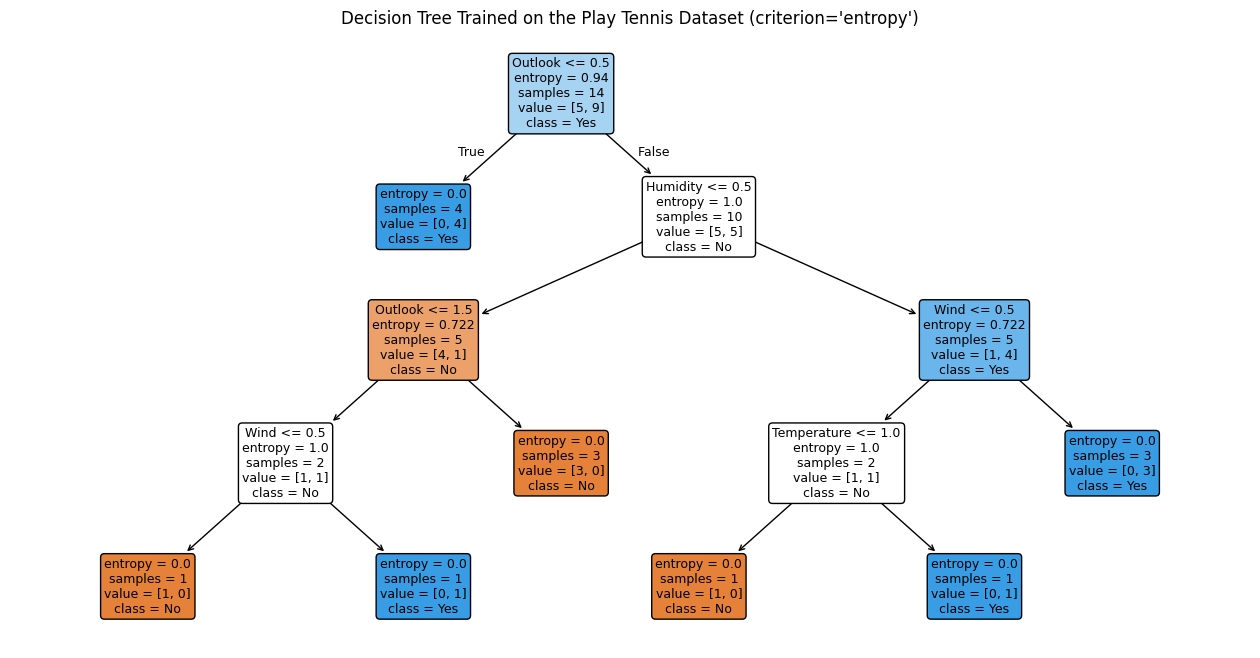

Notice: the root split is on 'Outlook' -- exactly matching our manual Information Gain calculation!


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OrdinalEncoder

X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = df['Play']

encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_encoded, y)

plt.figure(figsize=(16, 8))
plot_tree(clf, feature_names=['Outlook', 'Temperature', 'Humidity', 'Wind'],
          class_names=clf.classes_, filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree Trained on the Play Tennis Dataset (criterion='entropy')")
plt.show()

print("Notice: the root split is on 'Outlook' -- exactly matching our manual Information Gain calculation!")


## 6. Splitting a Continuous Feature — Trying Every Threshold

Section 7 of the notes explains that continuous features don't have natural categories — the algorithm
tries every candidate threshold between consecutive sorted values. Let's do that manually for `Humidity`
(if we treat it as a numeric percentage) using a small synthetic numeric version.

In [ ]:
# A small synthetic numeric feature + binary target, just to demonstrate threshold search
np.random.seed(0)
humidity_values = np.array([85, 90, 78, 96, 80, 70, 65, 95, 70, 80, 91, 90, 85, 87])
play = df['Play'].values

sorted_idx = np.argsort(humidity_values)
sorted_humidity = humidity_values[sorted_idx]
sorted_play = play[sorted_idx]

candidate_thresholds = (sorted_humidity[:-1] + sorted_humidity[1:]) / 2
root_e = entropy(play)

results = []
for t in candidate_thresholds:
    left_mask = humidity_values <= t
    right_mask = ~left_mask
    if left_mask.sum() == 0 or right_mask.sum() == 0:
        continue
    weighted = (left_mask.sum()/len(play))*entropy(play[left_mask]) + \
               (right_mask.sum()/len(play))*entropy(play[right_mask])
    ig = root_e - weighted
    results.append((t, ig))

results_df = pd.DataFrame(results, columns=['Threshold', 'Information Gain']).sort_values('Information Gain', ascending=False)
results_df.head(10)


,Threshold,Information Gain
4,80.0,0.090276
5,82.5,0.090276
6,85.0,0.048127
7,86.0,0.048127
0,67.5,0.047709
12,95.5,0.047709
3,79.0,0.014956
11,93.0,0.010318
8,88.5,0.003185
1,70.0,0.000489


Best threshold found: Humidity <= 80.0 (Information Gain = 0.0903)


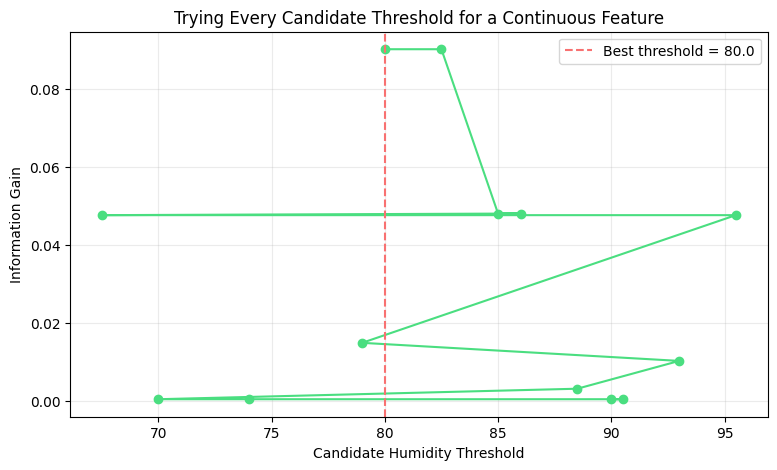

In [ ]:
best_threshold = results_df.iloc[0]['Threshold']
best_ig = results_df.iloc[0]['Information Gain']
print(f"Best threshold found: Humidity <= {best_threshold} (Information Gain = {best_ig:.4f})")

plt.figure(figsize=(9, 5))
plt.plot(results_df['Threshold'], results_df['Information Gain'], marker='o', color="#4ade80")
plt.axvline(best_threshold, color="#f87171", linestyle="--", label=f"Best threshold = {best_threshold}")
plt.xlabel("Candidate Humidity Threshold")
plt.ylabel("Information Gain")
plt.title("Trying Every Candidate Threshold for a Continuous Feature")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 7. Pre-Pruning vs Post-Pruning — Overfitting in Action

The 14-row Play Tennis dataset is too small to show a convincing overfitting curve, so let's switch to a
larger synthetic dataset for this demo — exactly the kind of dataset where pruning actually matters.

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_big, y_big = make_classification(n_samples=1000, n_features=10, n_informative=6,
                                     n_redundant=2, random_state=42)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_big, y_big, test_size=0.25, random_state=42)

# Fully-grown tree (no pruning at all)
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(Xb_train, yb_train)
print("Fully-Grown Tree (no pruning):")
print(f"  Train Accuracy: {accuracy_score(yb_train, full_tree.predict(Xb_train)):.3f}")
print(f"  Test Accuracy:  {accuracy_score(yb_test, full_tree.predict(Xb_test)):.3f}")
print(f"  Tree depth: {full_tree.get_depth()}, Leaves: {full_tree.get_n_leaves()}")


Fully-Grown Tree (no pruning):
  Train Accuracy: 1.000
  Test Accuracy:  0.832
  Tree depth: 10, Leaves: 74


### 7.1 Pre-Pruning — Restricting Growth with `max_depth`

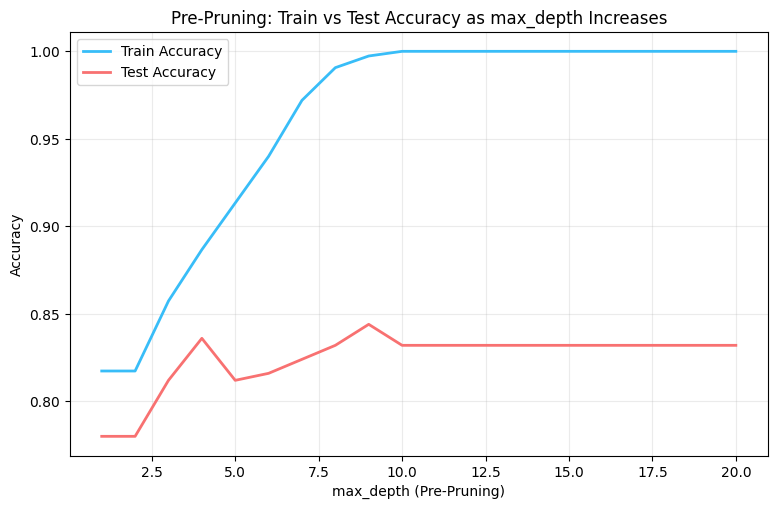

Best max_depth for TEST accuracy: 9 (test acc = 0.844)
Notice how test accuracy peaks then plateaus/declines while train accuracy keeps climbing -- overfitting!


In [ ]:
depths = range(1, 21)
train_accs, test_accs = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(Xb_train, yb_train)
    train_accs.append(accuracy_score(yb_train, t.predict(Xb_train)))
    test_accs.append(accuracy_score(yb_test, t.predict(Xb_test)))

plt.figure(figsize=(9, 5.5))
plt.plot(depths, train_accs, label="Train Accuracy", color="#38bdf8", linewidth=2)
plt.plot(depths, test_accs, label="Test Accuracy", color="#f87171", linewidth=2)
plt.xlabel("max_depth (Pre-Pruning)")
plt.ylabel("Accuracy")
plt.title("Pre-Pruning: Train vs Test Accuracy as max_depth Increases")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

best_depth = depths[int(np.argmax(test_accs))]
print(f"Best max_depth for TEST accuracy: {best_depth} (test acc = {max(test_accs):.3f})")
print("Notice how test accuracy peaks then plateaus/declines while train accuracy keeps climbing -- overfitting!")


### 7.2 Post-Pruning — Cost-Complexity Pruning with `ccp_alpha`

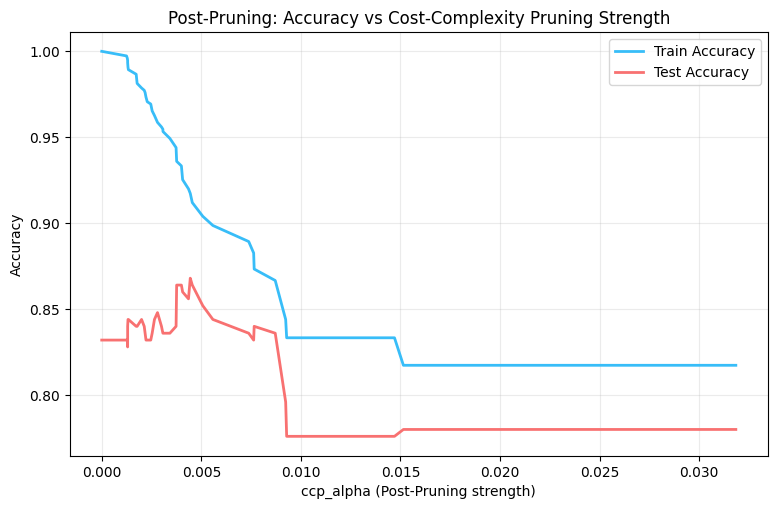

Best ccp_alpha for TEST accuracy: 0.00445 (test acc = 0.868)


In [ ]:
path = full_tree.cost_complexity_pruning_path(Xb_train, yb_train)
ccp_alphas = path.ccp_alphas[:-1]  # drop the trivial single-node-tree alpha

train_accs_ccp, test_accs_ccp = [], []
for alpha in ccp_alphas:
    t = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    t.fit(Xb_train, yb_train)
    train_accs_ccp.append(accuracy_score(yb_train, t.predict(Xb_train)))
    test_accs_ccp.append(accuracy_score(yb_test, t.predict(Xb_test)))

plt.figure(figsize=(9, 5.5))
plt.plot(ccp_alphas, train_accs_ccp, label="Train Accuracy", color="#38bdf8", linewidth=2)
plt.plot(ccp_alphas, test_accs_ccp, label="Test Accuracy", color="#f87171", linewidth=2)
plt.xlabel("ccp_alpha (Post-Pruning strength)")
plt.ylabel("Accuracy")
plt.title("Post-Pruning: Accuracy vs Cost-Complexity Pruning Strength")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

best_alpha = ccp_alphas[int(np.argmax(test_accs_ccp))]
print(f"Best ccp_alpha for TEST accuracy: {best_alpha:.5f} (test acc = {max(test_accs_ccp):.3f})")




-  Manually computing Entropy/Gini/Information Gain on the Play Tennis dataset **matches the notes
  exactly** — `Outlook` wins as the root split with the highest Information Gain (~0.247).
-  Entropy peaks at **1**, Gini Impurity peaks at **0.5** — both hit 0 for pure nodes.
-  `sklearn`'s trained tree **independently confirms** `Outlook` as the root — validating the manual math.
-  Continuous features are split by **brute-force testing every candidate threshold** — exactly as
  Section 7 of the notes describes.
-  A fully-grown tree **overfits** (high train accuracy, lower test accuracy) — both **Pre-Pruning**
  (`max_depth`) and **Post-Pruning** (`ccp_alpha`) fix this, and this notebook shows *exactly* where
  the sweet spot is for each.

